# Importando Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import keras
from keras import layers
from keras.optimizers import Adam
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences

# Find out if using GPU
gpu = !nvidia-smi -L
print(gpu[0].split(' (')[0] if gpu[0].startswith('GPU') else 'Not using GPU')

# For more GPU information, run:
# !nvidia-smi

2025-07-08 12:42:14.828331: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751978535.052089      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751978535.113935      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


GPU 0: Tesla P100-PCIE-16GB


In [2]:
import pandas as pd

def dataframe_to_3d_blocks(df, drop_column='ecg_id', block_size=1000):
  
    # Remove a coluna especificada
    df_drop = df.drop(drop_column, axis=1)

    # Converte para NumPy
    X = df_drop.to_numpy()

    # Calcula o número de blocos possíveis
    n_blocks = X.shape[0] // block_size

    # Trunca o array para múltiplos exatos de block_size
    X = X[:n_blocks * block_size]

    # Reshape para 3D
    X_3d = X.reshape(n_blocks, block_size, -1)

    return X_3d

In [3]:
x_train = dataframe_to_3d_blocks(pd.read_csv('/kaggle/input/dados-preprocess/y_train_signal(1).csv'))
x_val = dataframe_to_3d_blocks(pd.read_csv('/kaggle/input/dados-preprocess/y_valid_signal(1).csv'))
x_test = dataframe_to_3d_blocks(pd.read_csv('/kaggle/input/dados-preprocess/y_test_signal(1).csv'))

In [4]:
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(17441, 1000, 12)
(2193, 1000, 12)
(2203, 1000, 12)


In [5]:
y_train_all = pd.read_csv('/kaggle/input/dados-preprocess/y_train(2).csv')


In [6]:
y_train_class = y_train_all.loc[:, 'NORM':'CD']
y_train_subclass = y_train_all.loc[:, 'sub_NORM':'sub_PMI']

In [7]:
y_val_all = pd.read_csv('/kaggle/input/dados-preprocess/y_valid(1).csv')
y_val_class = y_val_all.loc[:, 'NORM':'CD']
y_val_subclass = y_val_all.loc[:, 'sub_NORM':'sub_PMI']

y_test_all = pd.read_csv('/kaggle/input/dados-preprocess/y_test(1).csv')
y_test_class = y_test_all.loc[:, 'NORM':'CD']
y_test_subclass = y_test_all.loc[:, 'sub_NORM':'sub_PMI']

In [8]:
print(y_train_class.shape)
print(y_val_class.shape)
print(y_test_class.shape)

(17441, 5)
(2193, 5)
(2203, 5)


## Declarando funções

In [9]:
import tensorflow as tf

class AUC_Macro(tf.keras.metrics.Metric):
    def __init__(self, num_labels, name="auc_macro", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_labels = num_labels
        self.auc_per_label = [
            tf.keras.metrics.AUC(name=f"auc_label_{i}") for i in range(num_labels)
        ]

    def update_state(self, y_true, y_pred, sample_weight=None):
        for i in range(self.num_labels):
            self.auc_per_label[i].update_state(
                y_true[:, i], y_pred[:, i], sample_weight
            )

    def result(self):
        return tf.reduce_mean([m.result() for m in self.auc_per_label])

    def reset_state(self):
        for m in self.auc_per_label:
            m.reset_state()


In [10]:
def train_class(model, epochs, batch_size, lr, callbacks, n_classes):
    from tqdm.keras import TqdmCallback
    import tensorflow as tf
    from tensorflow import keras

    auc_macro = AUC_Macro(num_labels=n_classes)

    callbacks = callbacks + [TqdmCallback(verbose=0)]
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[auc_macro]
    )
    history = model.fit(
        x_train, y_train_class,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(x_val, y_val_class),
        callbacks=callbacks,
        verbose=1  # mostra progresso no terminal
    )
    return history

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc, f1_score

def avaliar_modelo_multilabel(class_names=None, threshold=0.5):

    y_true = y_val_class.to_numpy() if hasattr(y_val_class, 'to_numpy') else y_val_class
    y_pred = model.predict(x_val)
    
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n_classes = y_true.shape[1]
    
    if class_names is None:
        class_names = [
            "NORM",       # Normal ECG
            "MI",         # Myocardial Infarction
            "STTC",       # ST/T Change
            "HYP",        # Hypertrophy
            "CD"          # Conduction Disturbance
        ]
    # Binariza previsões
    y_pred_bin = (y_pred > threshold).astype(int)

    # AUC
    auc_macro = roc_auc_score(y_true, y_pred, average="macro")
    print(f"\nAUC Macro: {auc_macro:.4f}")
    for i in range(n_classes):
        class_auc = roc_auc_score(y_true[:, i], y_pred[:, i])
        print(f"AUC {class_names[i]}: {class_auc:.4f}")

 
    # Plot ROC
    plt.figure(figsize=(10, 8))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Curvas ROC por Classe")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


In [12]:
def avaliar_teste_ptbxl(
    model,
    x_test,
    y_test_class,
    threshold: float = 0.5,
    index_name: str = "Modelo",
    results_df: pd.DataFrame | None = None,
):
    """
    Avalia o modelo no conjunto de teste do PTB-XL, imprime métricas, plota ROC
    e devolve (ou atualiza) um DataFrame acumulado de resultados.
    """
    class_names = ["NORM", "MI", "STTC", "HYP", "CD"]

    y_true = y_test_class.to_numpy() if hasattr(y_test_class, "to_numpy") else y_test_class
    y_pred = model.predict(x_test, verbose=0)
    y_pred_bin = (y_pred > threshold).astype(int)

    test_loss, _ = model.evaluate(x_test, y_true, verbose=0)
    auc_macro = roc_auc_score(y_true, y_pred, average="macro")

    auc_per_class = [
        roc_auc_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])
    ]

    new_row = {
        "loss": test_loss,
        "auc_macro": auc_macro,
        **{f"auc_{cls}": auc_c for cls, auc_c in zip(class_names, auc_per_class)},
    }

    # Cria o DataFrame com colunas certas se ainda não existir
    if results_df is None or results_df.empty:
        all_columns = list(new_row.keys())
        results_df = pd.DataFrame(columns=all_columns)

    # Adiciona nova linha
    results_df.loc[index_name] = new_row

    # Plot ROC
    plt.figure(figsize=(10, 8))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{cls} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Curvas ROC por Classe (Teste)")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    return results_df


In [13]:
def plots(history, xlim=None, ylim=None):
  if hasattr(history, 'history'):
    history = history.history
  plt.figure(figsize=(14, 4))
  plt.subplot(1, 2, 1)
  plt.plot(history['loss'], '.-', label='Train loss')
  if 'val_loss' in history.keys():
    plt.plot(history['val_loss'], '.-', label='Val loss')
  plt.xlabel('Epochs');
  plt.legend();
  plt.yscale('log')
  plt.grid(which='both');
  metrics = [m for m in history.keys() if not (m == 'loss' or m.startswith('val_') or m.startswith('Unnamed'))]
  if len(metrics) == 0: return
  plt.subplot(1, 2, 2)
  plt.plot(history[metrics[0]], '.-', label='Train ' + metrics[0])
  plt.xlabel('Epochs');
  if 'val_' + metrics[0] in history.keys():
    v = list(history['val_' + metrics[0]])
    plt.plot(v, '.-', label='Val ' + metrics[0])
    plt.title(f"Val {metrics[0]}: {max(v):.1%} (max) | {v[-1]:.1%} (last)");
  plt.legend();
  plt.xlim(xlim);
  plt.ylim(ylim);
  plt.grid();

# Modelo RNN LSTM

In [15]:
def get_model():
    model = keras.Sequential([
        # Entrada com sequência temporal e 12 canais (derivações do ECG)
        layers.Input(shape=(1000, 12)),  # input_len = número de amostras por traçado
        
        # LSTM com 100 unidades
        layers.LSTM(100),
        
        layers.Dense(128, activation='relu'),
        # Camada densa para saída binária (ajuste se for multi-classe)
        layers.Dense(5, activation='sigmoid')  
    ])
    
    return model

get_model().summary()


I0000 00:00:1751978637.340178      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100)                 │          45,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          12,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 58,773 (229.58 KB)

 Trainable params: 58,773 (229.58 KB)

 Non-trainable params: 0 (0.00 B)

## Resultados Validação

0epoch [00:00, ?epoch/s]

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step - auc_macro: 0.5357 - loss: 0.5629 - val_auc_macro: 0.5494 - val_loss: 0.5415
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - auc_macro: 0.6277 - loss: 0.5132 - val_auc_macro: 0.8311 - val_loss: 0.4072
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - auc_macro: 0.8461 - loss: 0.3751 - val_auc_macro: 0.8795 - val_loss: 0.3436
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - auc_macro: 0.8944 - loss: 0.3165 - val_auc_macro: 0.8943 - val_loss: 0.3217
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - auc_macro: 0.9036 - loss: 0.3042 - val_auc_macro: 0.8999 - val_loss: 0.3132
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - auc_macro: 0.9167 - loss: 0.2833 - val_auc_macro: 0.8982 - val_loss: 0.3256
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - auc_macro: 0.9162 - loss: 0.2810 - val_auc_macro: 0.9075 - val_loss: 0.3033
Epoch 8/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - auc_macro: 0.9272 - loss: 0

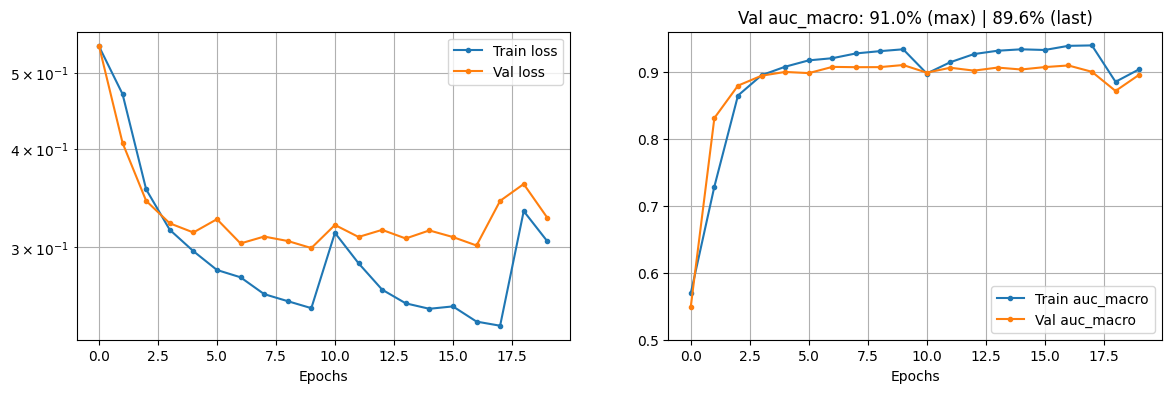

In [94]:
model = get_model()
history = train_class(model, epochs=20, batch_size=128, lr=0.01, callbacks=[], n_classes=5)
plots(history, ylim=[0.5, 0.96])

69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step

AUC Macro: 0.8959
AUC NORM: 0.9342
AUC MI: 0.8861
AUC STTC: 0.9061
AUC HYP: 0.8844
AUC CD: 0.8688


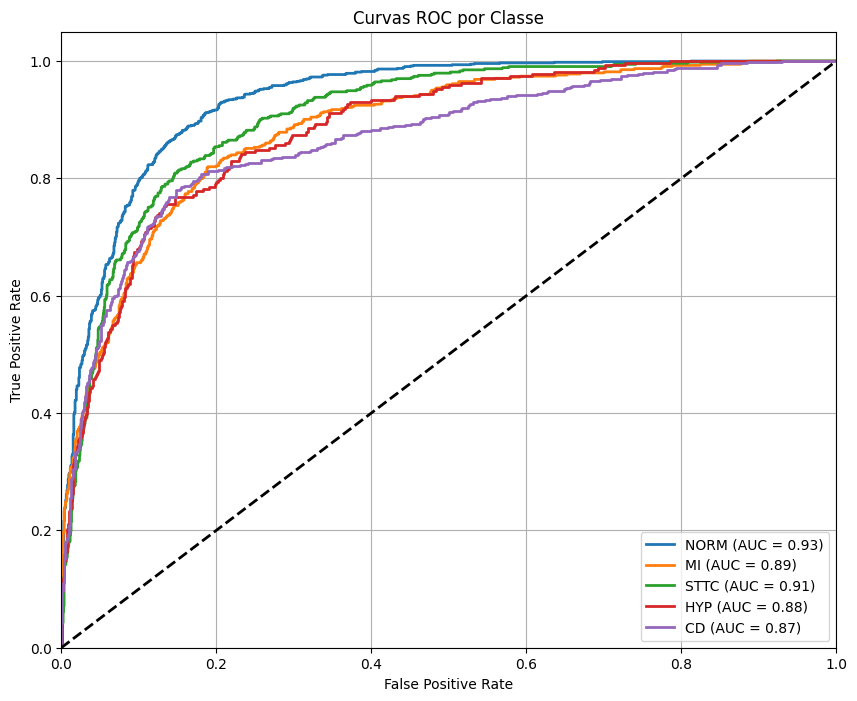

In [95]:
avaliar_modelo_multilabel()

## Resultados Teste

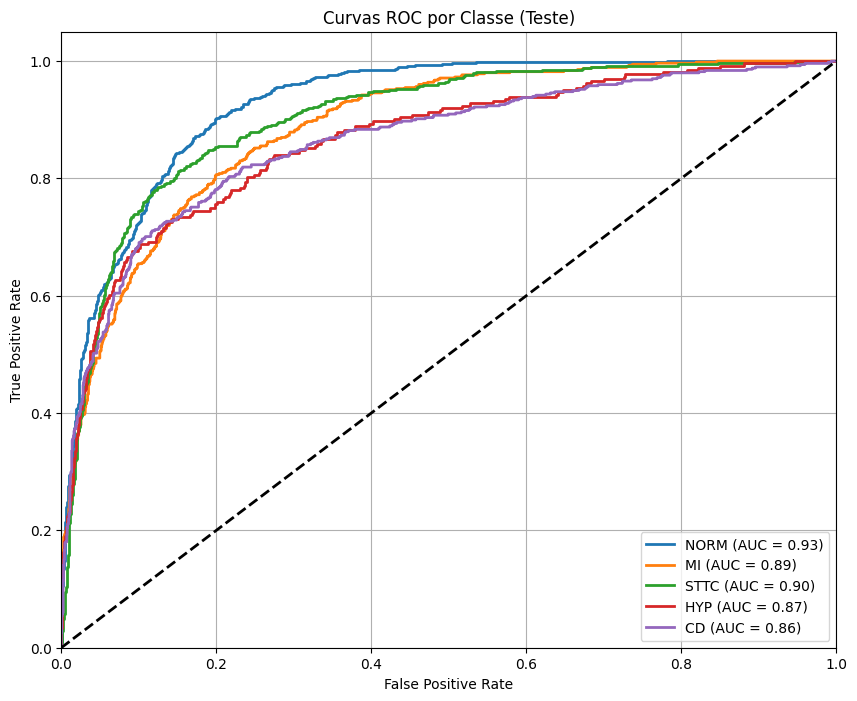

,loss,auc_macro,auc_NORM,auc_MI,auc_STTC,auc_HYP,auc_CD
LSTM Básico,0.33378,0.889028,0.926611,0.887513,0.903004,0.865178,0.862836


In [102]:
df_resultados_teste = avaliar_teste_ptbxl(model, x_test, y_test_class, index_name="LSTM Básico")
display(df_resultados_teste)

# Modelo RNN GRU

In [103]:
def get_model():
    model = keras.Sequential([
        # Entrada com sequência temporal e 12 canais (derivações do ECG)
        layers.Input(shape=(1000, 12)),  # input_len = número de amostras por traçado
        
        # LSTM com 100 unidades
        layers.GRU(100),
        
        layers.Dense(128, activation='relu'),
        # Camada densa para saída binária (ajuste se for multi-classe)
        layers.Dense(5, activation='sigmoid')  
    ])
    
    return model

get_model().summary()


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                          │ (None, 100)                 │          34,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 128)                 │          12,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 47,773 (186.61 KB)

 Trainable params: 47,773 (186.61 KB)

 Non-trainable params: 0 (0.00 B)

## Resultados Validação

0epoch [00:00, ?epoch/s]

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step - auc_macro: 0.5449 - loss: 0.5523 - val_auc_macro: 0.5505 - val_loss: 0.5477
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - auc_macro: 0.6492 - loss: 0.5036 - val_auc_macro: 0.8415 - val_loss: 0.3875
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - auc_macro: 0.8502 - loss: 0.3722 - val_auc_macro: 0.8706 - val_loss: 0.3783
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - auc_macro: 0.8777 - loss: 0.3400 - val_auc_macro: 0.8869 - val_loss: 0.3367
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - auc_macro: 0.8963 - loss: 0.3163 - val_auc_macro: 0.8939 - val_loss: 0.3332
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - auc_macro: 0.9069 - loss: 0.2971 - val_auc_macro: 0.9009 - val_loss: 0.3228
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - auc_macro: 0.9175 - loss: 0.2803 - val_auc_macro: 0.9019 - val_loss: 0.3158
Epoch 8/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - auc_macro: 0.9229 - loss: 0

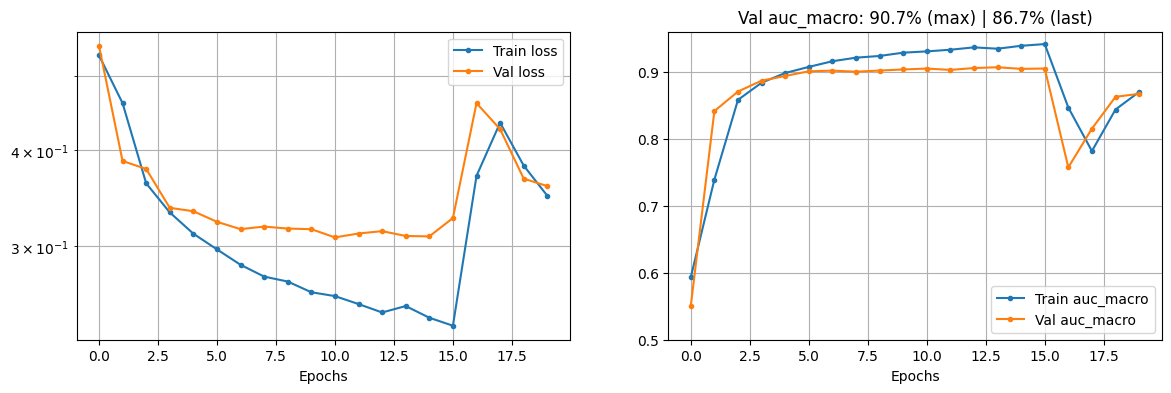

In [106]:
model = get_model()
history = train_class(model, epochs=20, batch_size=128, lr=0.01, callbacks=[], n_classes=5)
plots(history, ylim=[0.5, 0.96])

69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step

AUC Macro: 0.8672
AUC NORM: 0.9113
AUC MI: 0.8616
AUC STTC: 0.8852
AUC HYP: 0.8501
AUC CD: 0.8278


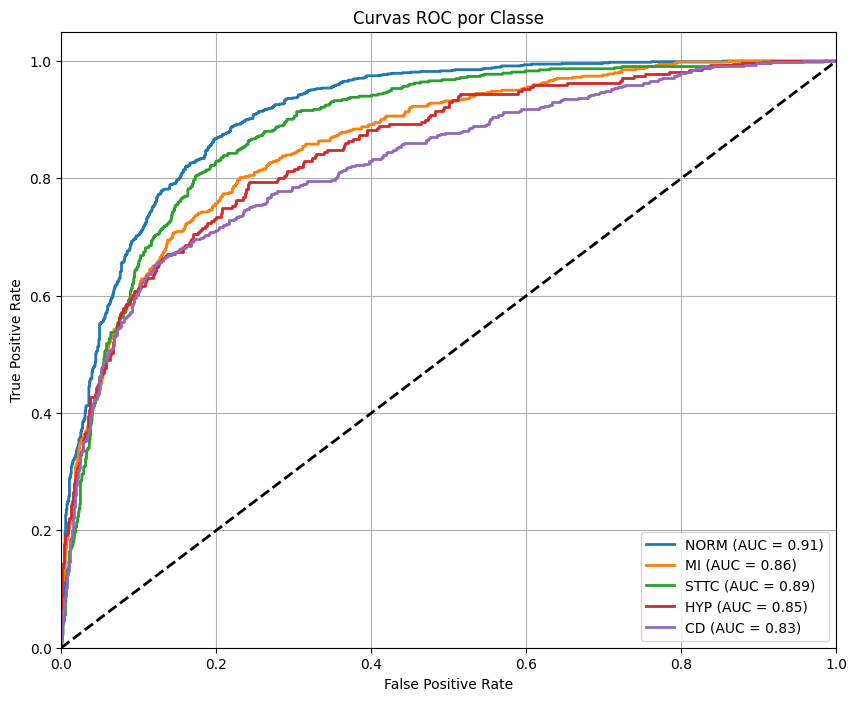

In [107]:
avaliar_modelo_multilabel()

## Resultados Teste

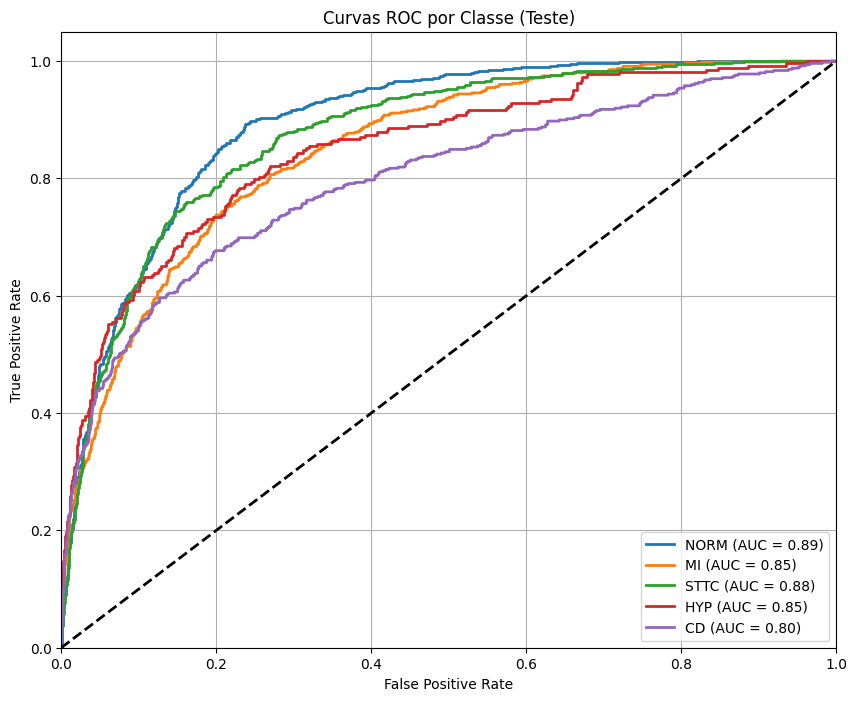

,loss,auc_macro,auc_NORM,auc_MI,auc_STTC,auc_HYP,auc_CD
LSTM Básico,0.333780,0.889028,0.926611,0.887513,0.903004,0.865178,0.862836
GRU Básico,0.371202,0.853276,0.893860,0.849386,0.875130,0.850218,0.797785


In [108]:
df_resultados_teste = avaliar_teste_ptbxl(model, x_test, y_test_class, index_name="GRU Básico", results_df=df_resultados_teste)

display(df_resultados_teste)

# Com LearningRateScheduler

## LSTM

In [109]:
def get_model():
    model = keras.Sequential([
        # Entrada com sequência temporal e 12 canais (derivações do ECG)
        layers.Input(shape=(1000, 12)),  # input_len = número de amostras por traçado
        
        # LSTM com 100 unidades
        layers.LSTM(100),
        
        layers.Dense(128, activation='relu'),
        # Camada densa para saída binária (ajuste se for multi-classe)
        layers.Dense(5, activation='sigmoid')  
    ])
    
    return model

get_model().summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                        │ (None, 100)                 │          45,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 128)                 │          12,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 58,773 (229.58 KB)

 Trainable params: 58,773 (229.58 KB)

 Non-trainable params: 0 (0.00 B)

In [110]:
from tensorflow.keras.callbacks import LearningRateScheduler

# Função para decaimento da taxa de aprendizado
def scheduler(epoch, lr):
    if epoch > 0 and epoch % 2 == 0:
        return lr * 0.5
    return lr

lr_callback = LearningRateScheduler(scheduler)

## Resultados Validação


0epoch [00:00, ?epoch/s]

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - auc_macro: 0.5395 - loss: 0.5583 - val_auc_macro: 0.6470 - val_loss: 0.5202 - learning_rate: 0.0100
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - auc_macro: 0.6249 - loss: 0.5186 - val_auc_macro: 0.6605 - val_loss: 0.5056 - learning_rate: 0.0100
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - auc_macro: 0.6820 - loss: 0.4894 - val_auc_macro: 0.7877 - val_loss: 0.4545 - learning_rate: 0.0050
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - auc_macro: 0.7945 - loss: 0.4197 - val_auc_macro: 0.8047 - val_loss: 0.4172 - learning_rate: 0.0050
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - auc_macro: 0.8366 - loss: 0.3854 - val_auc_macro: 0.8547 - val_loss: 0.3729 - learning_rate: 0.0025
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - auc_macro: 0.8633 - loss: 0.3554 - val_auc_macro: 0.8646 - val_loss: 0.3658 - learning_rate: 0.0025
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - auc_macro: 0.8

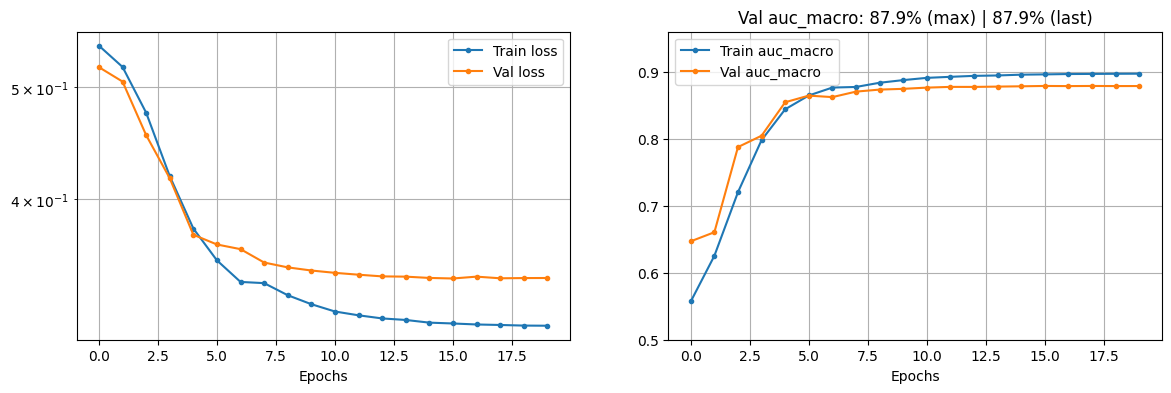

In [111]:
model = get_model()
history = train_class(model, epochs=20, batch_size=128, lr=0.01, callbacks=[lr_callback], n_classes=5)
plots(history, ylim=[0.5, 0.96])

## Resultados Teste

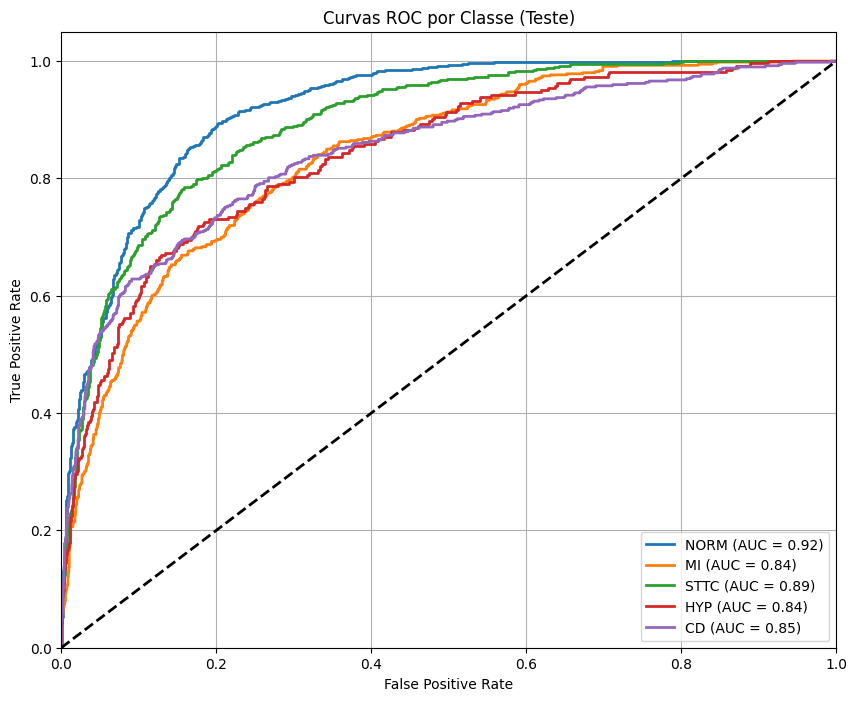

,loss,auc_macro,auc_NORM,auc_MI,auc_STTC,auc_HYP,auc_CD
LSTM Básico,0.333780,0.889028,0.926611,0.887513,0.903004,0.865178,0.862836
GRU Básico,0.371202,0.853276,0.893860,0.849386,0.875130,0.850218,0.797785
LSTM LearningRateScheduler,0.351792,0.868637,0.919697,0.840285,0.894060,0.843744,0.845399


In [112]:
df_resultados_teste = avaliar_teste_ptbxl(model, x_test, y_test_class, index_name="LSTM LearningRateScheduler", results_df=df_resultados_teste)

display(df_resultados_teste)

## GRU

In [113]:
def get_model():
    model = keras.Sequential([
        # Entrada com sequência temporal e 12 canais (derivações do ECG)
        layers.Input(shape=(1000, 12)),  # input_len = número de amostras por traçado
        
        # LSTM com 100 unidades
        layers.GRU(100),
        
        layers.Dense(128, activation='relu'),
        # Camada densa para saída binária (ajuste se for multi-classe)
        layers.Dense(5, activation='sigmoid')  
    ])
    
    return model

get_model().summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_7 (GRU)                          │ (None, 100)                 │          34,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 128)                 │          12,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 47,773 (186.61 KB)

 Trainable params: 47,773 (186.61 KB)

 Non-trainable params: 0 (0.00 B)

In [114]:
# Função para decaimento da taxa de aprendizado
def scheduler(epoch, lr):
    if epoch > 0 and epoch % 2 == 0:
        return lr * 0.5
    return lr

lr_callback = LearningRateScheduler(scheduler)

## Resultados Validação

0epoch [00:00, ?epoch/s]

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 14s 79ms/step - auc_macro: 0.5530 - loss: 0.5676 - val_auc_macro: 0.7881 - val_loss: 0.4322 - learning_rate: 0.0100
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - auc_macro: 0.8256 - loss: 0.3944 - val_auc_macro: 0.8866 - val_loss: 0.3361 - learning_rate: 0.0100
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - auc_macro: 0.9014 - loss: 0.3039 - val_auc_macro: 0.9015 - val_loss: 0.3104 - learning_rate: 0.0050
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - auc_macro: 0.9165 - loss: 0.2817 - val_auc_macro: 0.9065 - val_loss: 0.3038 - learning_rate: 0.0050
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - auc_macro: 0.9299 - loss: 0.2575 - val_auc_macro: 0.9088 - val_loss: 0.2981 - learning_rate: 0.0025
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - auc_macro: 0.9319 - loss: 0.2562 - val_auc_macro: 0.9102 - val_loss: 0.3019 - learning_rate: 0.0025
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - auc_macro: 0.9

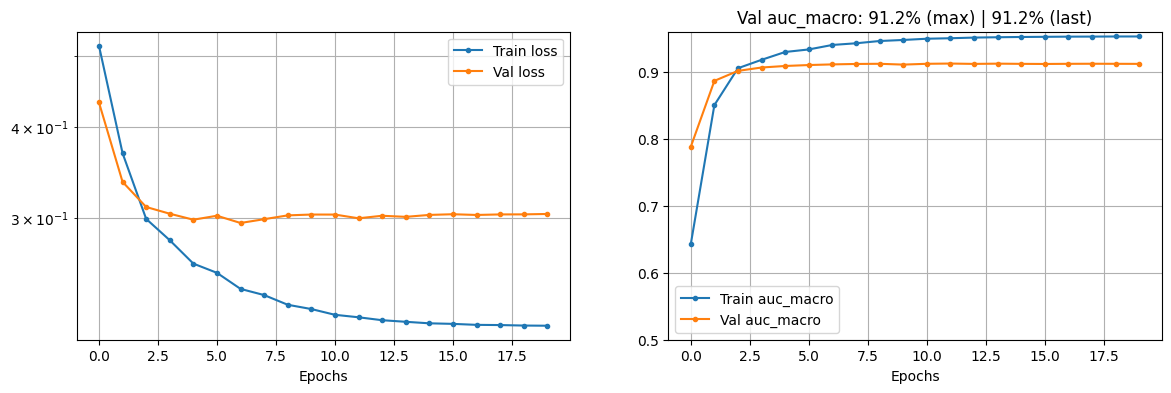

In [115]:
model = get_model()
history = train_class(model, epochs=20, batch_size=128, lr=0.01, callbacks=[lr_callback], n_classes=5)
plots(history, ylim=[0.5, 0.96])

## Resultados Teste

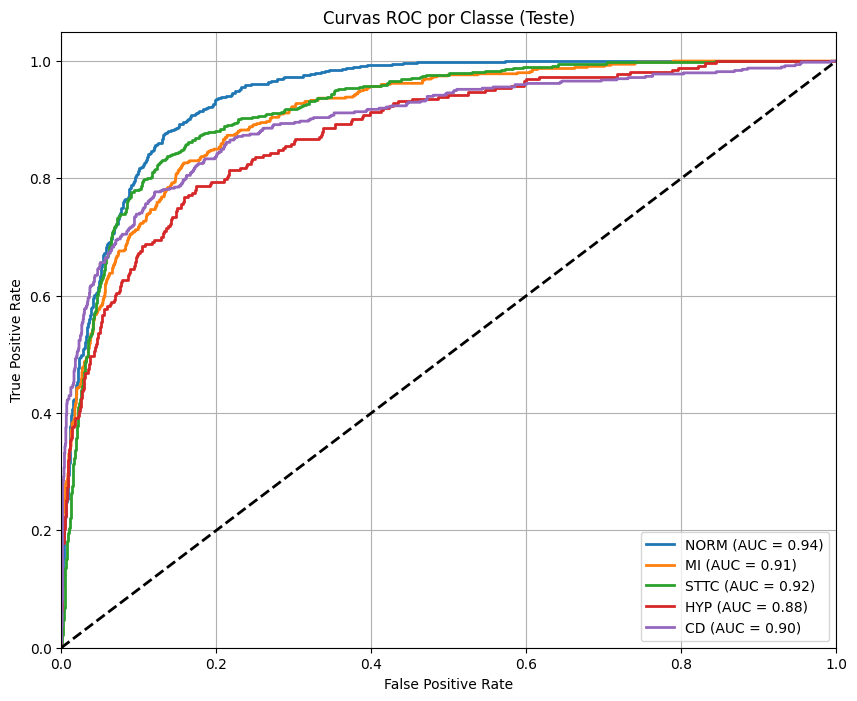

,loss,auc_macro,auc_NORM,auc_MI,auc_STTC,auc_HYP,auc_CD
LSTM Básico,0.333780,0.889028,0.926611,0.887513,0.903004,0.865178,0.862836
GRU Básico,0.371202,0.853276,0.893860,0.849386,0.875130,0.850218,0.797785
LSTM LearningRateScheduler,0.351792,0.868637,0.919697,0.840285,0.894060,0.843744,0.845399
GRU LearningRateScheduler,0.306927,0.909020,0.941086,0.909609,0.918277,0.878799,0.897331


In [116]:
df_resultados_teste = avaliar_teste_ptbxl(model, x_test, y_test_class, index_name="GRU LearningRateScheduler", results_df=df_resultados_teste)

display(df_resultados_teste)

# Com Reduce LR On Plateau

## LSTM

In [117]:
def get_model():
    model = keras.Sequential([
        # Entrada com sequência temporal e 12 canais (derivações do ECG)
        layers.Input(shape=(1000, 12)),  # input_len = número de amostras por traçado
        
        # LSTM com 100 unidades
        layers.LSTM(100),
        
        layers.Dense(128, activation='relu'),
        # Camada densa para saída binária (ajuste se for multi-classe)
        layers.Dense(5, activation='sigmoid')  
    ])
    
    return model

get_model().summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                       │ (None, 100)                 │          45,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_40 (Dense)                     │ (None, 128)                 │          12,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 58,773 (229.58 KB)

 Trainable params: 58,773 (229.58 KB)

 Non-trainable params: 0 (0.00 B)

## Resultados Validação


### Patience=2

In [122]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_callback = ReduceLROnPlateau(
    monitor='val_loss',     # ou 'val_auc_macro' se você adicionou essa métrica
    factor=0.5,             # reduz LR pela metade
    patience=2,             # espera 2 épocas sem melhora
    min_lr=1e-6,            # limite inferior
    verbose=1
)


0epoch [00:00, ?epoch/s]

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - auc_macro: 0.5211 - loss: 0.5658 - val_auc_macro: 0.5354 - val_loss: 0.5406 - learning_rate: 0.0100
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.5499 - loss: 0.5344 - val_auc_macro: 0.6530 - val_loss: 0.5077 - learning_rate: 0.0100
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.6146 - loss: 0.5219 - val_auc_macro: 0.4969 - val_loss: 0.5523 - learning_rate: 0.0100
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - auc_macro: 0.5085 - loss: 0.5482
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.5086 - loss: 0.5481 - val_auc_macro: 0.5680 - val_loss: 0.5356 - learning_rate: 0.0100
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.5773 - loss: 0.5332 - val_auc_macro: 0.5994 - val_loss: 0.5268 - learning_rate: 0.0050
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - auc_macro: 0.6046

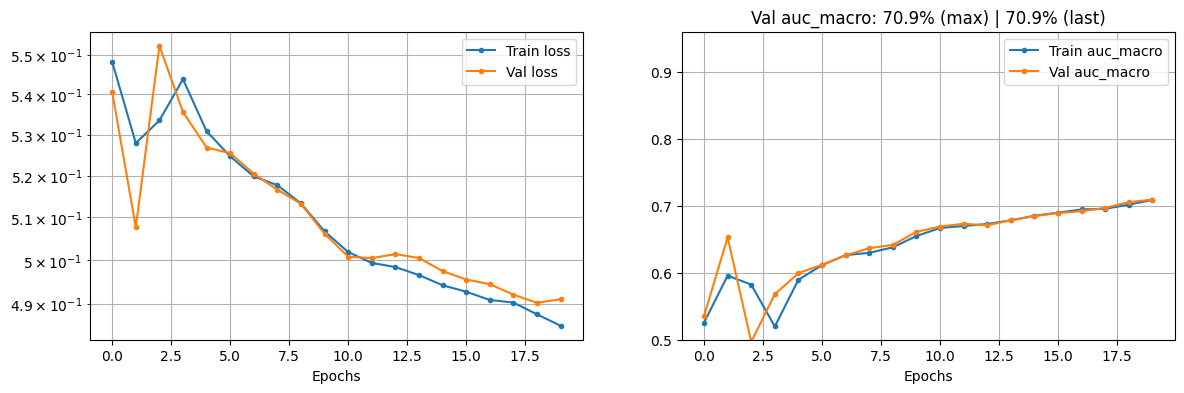

In [119]:
model = get_model()
history = train_class(model, epochs=20, batch_size=128, lr=0.01, callbacks=[lr_callback], n_classes=5)
plots(history, ylim=[0.5, 0.96])

### Patience=5

In [124]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_callback = ReduceLROnPlateau(
    monitor='val_loss',     # ou 'val_auc_macro' se você adicionou essa métrica
    factor=0.5,             # reduz LR pela metade
    patience=5,             # espera X épocas sem melhora
    min_lr=1e-6,            # limite inferior
    verbose=1
)


0epoch [00:00, ?epoch/s]

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - auc_macro: 0.5214 - loss: 0.5695 - val_auc_macro: 0.5676 - val_loss: 0.5363 - learning_rate: 0.0100
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.5399 - loss: 0.5382 - val_auc_macro: 0.6569 - val_loss: 0.5132 - learning_rate: 0.0100
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.6428 - loss: 0.5081 - val_auc_macro: 0.7191 - val_loss: 0.4945 - learning_rate: 0.0100
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.6994 - loss: 0.4870 - val_auc_macro: 0.7673 - val_loss: 0.4686 - learning_rate: 0.0100
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - auc_macro: 0.7879 - loss: 0.4307 - val_auc_macro: 0.8225 - val_loss: 0.4073 - learning_rate: 0.0100
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.8335 - loss: 0.3897 - val_auc_macro: 0.8464 - val_loss: 0.3786 - learning_rate: 0.0100
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.8

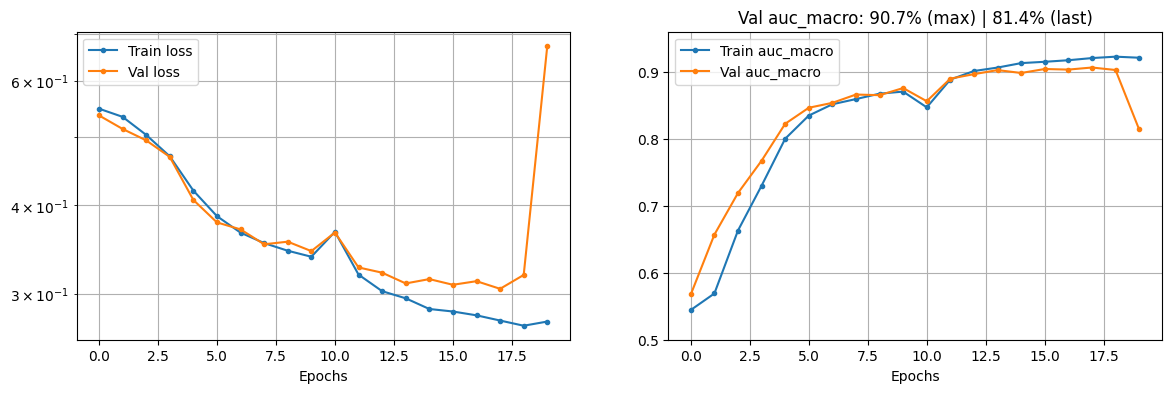

In [123]:
model = get_model()
history = train_class(model, epochs=20, batch_size=128, lr=0.01, callbacks=[lr_callback], n_classes=5)
plots(history, ylim=[0.5, 0.96])

### Patience=3

In [126]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_callback = ReduceLROnPlateau(
    monitor='val_loss',     # ou 'val_auc_macro' se você adicionou essa métrica
    factor=0.5,             # reduz LR pela metade
    patience=3,             # espera X épocas sem melhora
    min_lr=1e-6,            # limite inferior
    verbose=1
)


0epoch [00:00, ?epoch/s]

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step - auc_macro: 0.5269 - loss: 0.5568 - val_auc_macro: 0.6292 - val_loss: 0.5195 - learning_rate: 0.0100
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - auc_macro: 0.5714 - loss: 0.5341 - val_auc_macro: 0.4862 - val_loss: 0.5576 - learning_rate: 0.0100
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - auc_macro: 0.5035 - loss: 0.5439 - val_auc_macro: 0.5334 - val_loss: 0.5435 - learning_rate: 0.0100
Epoch 4/20
136/137 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - auc_macro: 0.5157 - loss: 0.5401
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - auc_macro: 0.5158 - loss: 0.5401 - val_auc_macro: 0.5500 - val_loss: 0.5413 - learning_rate: 0.0100
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - auc_macro: 0.5359 - loss: 0.5343 - val_auc_macro: 0.5544 - val_loss: 0.5393 - learning_rate: 0.0050
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - auc_macro: 0.5325

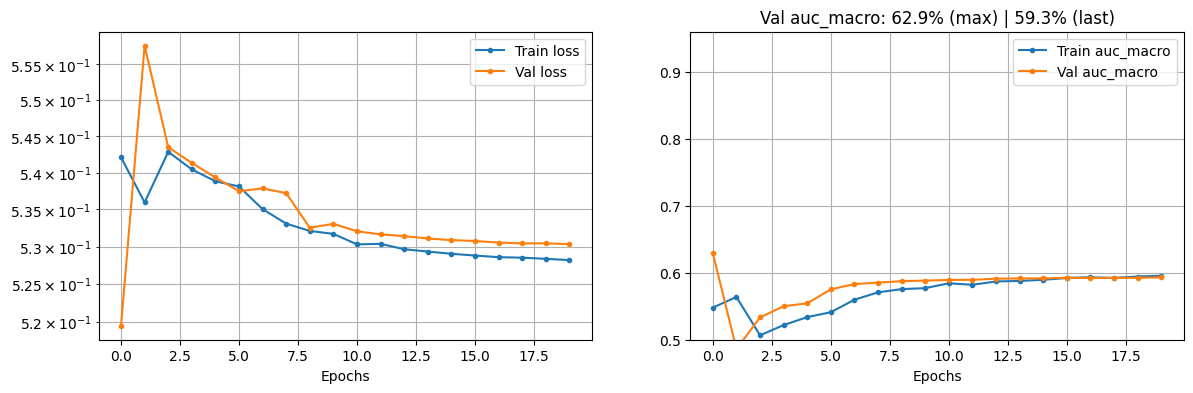

In [127]:
model = get_model()
history = train_class(model, epochs=20, batch_size=128, lr=0.01, callbacks=[lr_callback], n_classes=5)
plots(history, ylim=[0.5, 0.96])

### Patience=3 e Factor = 0.85

In [128]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_callback = ReduceLROnPlateau(
    monitor='val_loss',     # ou 'val_auc_macro' se você adicionou essa métrica
    factor=0.85,             # reduz LR pela metade
    patience=3,             # espera X épocas sem melhora
    min_lr=1e-6,            # limite inferior
    verbose=1
)


0epoch [00:00, ?epoch/s]

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - auc_macro: 0.5348 - loss: 0.5617 - val_auc_macro: 0.5456 - val_loss: 0.5396 - learning_rate: 0.0100
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.6073 - loss: 0.5221 - val_auc_macro: 0.7279 - val_loss: 0.4837 - learning_rate: 0.0100
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.7199 - loss: 0.4788 - val_auc_macro: 0.7423 - val_loss: 0.5129 - learning_rate: 0.0100
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.7808 - loss: 0.4345 - val_auc_macro: 0.5141 - val_loss: 0.5676 - learning_rate: 0.0100
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - auc_macro: 0.5331 - loss: 0.5449
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.008499999810010194.
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.5332 - loss: 0.5449 - val_auc_macro: 0.5574 - val_loss: 0.5397 - learning_rate: 0.0100
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.5643

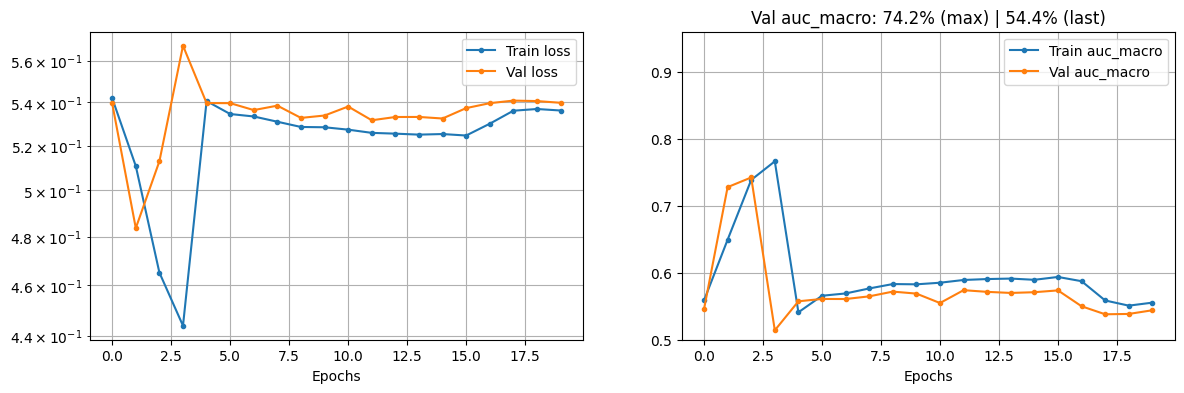

In [129]:
model = get_model()
history = train_class(model, epochs=20, batch_size=128, lr=0.01, callbacks=[lr_callback], n_classes=5)
plots(history, ylim=[0.5, 0.96])

### Patience=4 e Factor = 0.85

0epoch [00:00, ?epoch/s]

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - auc_macro: 0.5085 - loss: 0.5626 - val_auc_macro: 0.5393 - val_loss: 0.5413 - learning_rate: 0.0100
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - auc_macro: 0.5771 - loss: 0.5334 - val_auc_macro: 0.6994 - val_loss: 0.4994 - learning_rate: 0.0100
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.6998 - loss: 0.4847 - val_auc_macro: 0.6897 - val_loss: 0.6609 - learning_rate: 0.0100
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.5417 - loss: 0.5591 - val_auc_macro: 0.6146 - val_loss: 0.5549 - learning_rate: 0.0100
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - auc_macro: 0.5639 - loss: 0.5352 - val_auc_macro: 0.6182 - val_loss: 0.5258 - learning_rate: 0.0100
Epoch 6/20
136/137 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - auc_macro: 0.5991 - loss: 0.5264
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.008499999810010194.
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.5990

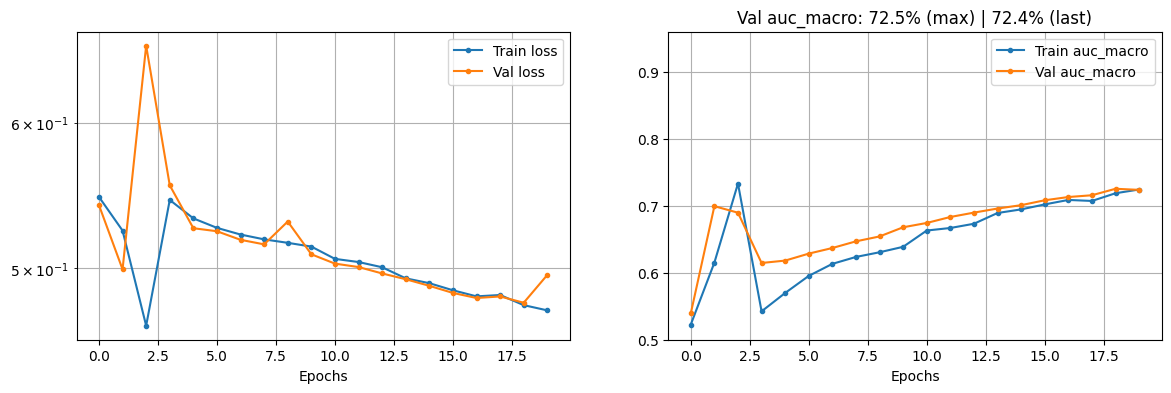

In [131]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_callback = ReduceLROnPlateau(
    monitor='val_loss',     # ou 'val_auc_macro' se você adicionou essa métrica
    factor=0.85,             # reduz LR pela metade
    patience=4,           # espera X épocas sem melhora
    min_lr=1e-6,            # limite inferior
    verbose=1
)

model = get_model()
history = train_class(model, epochs=20, batch_size=128, lr=0.01, callbacks=[lr_callback], n_classes=5)
plots(history, ylim=[0.5, 0.96])

### Patience=2, Factor = 0.85, lr = 0.05

0epoch [00:00, ?epoch/s]

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - auc_macro: 0.5141 - loss: 0.5807 - val_auc_macro: 0.5664 - val_loss: 0.5379 - learning_rate: 0.0500
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.5790 - loss: 0.5305 - val_auc_macro: 0.5446 - val_loss: 0.5416 - learning_rate: 0.0500
Epoch 3/20
136/137 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - auc_macro: 0.5265 - loss: 0.5389
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.02500000037252903.
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.5265 - loss: 0.5389 - val_auc_macro: 0.4999 - val_loss: 0.5442 - learning_rate: 0.0500
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.4938 - loss: 0.5418 - val_auc_macro: 0.5000 - val_loss: 0.5442 - learning_rate: 0.0250
Epoch 5/20
136/137 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - auc_macro: 0.4960 - loss: 0.5399
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.012500000186264515.
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.4960 - l

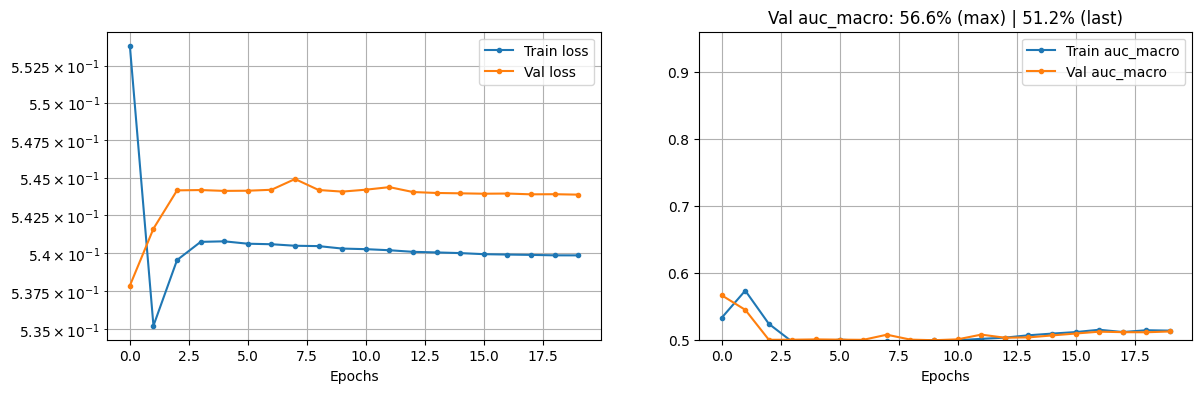

In [133]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_callback = ReduceLROnPlateau(
    monitor='val_loss',     # ou 'val_auc_macro' se você adicionou essa métrica
    factor=0.5,             # reduz LR pela metade
    patience=2,           # espera X épocas sem melhora
    min_lr=1e-6,            # limite inferior
    verbose=1
)

model = get_model()
history = train_class(model, epochs=20, batch_size=128, lr=0.05, callbacks=[lr_callback], n_classes=5)
plots(history, ylim=[0.5, 0.96])

### Patience=10, Factor = 0.5, epochs=100, batch_size=1024, lr = 0.01

0epoch [00:00, ?epoch/s]

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 288ms/step - auc_macro: 0.4980 - loss: 0.6205 - val_auc_macro: 0.5100 - val_loss: 0.5430 - learning_rate: 0.0100
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 204ms/step - auc_macro: 0.5030 - loss: 0.5440 - val_auc_macro: 0.5131 - val_loss: 0.5424 - learning_rate: 0.0100
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 205ms/step - auc_macro: 0.5025 - loss: 0.5424 - val_auc_macro: 0.5279 - val_loss: 0.5417 - learning_rate: 0.0100
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 206ms/step - auc_macro: 0.5240 - loss: 0.5405 - val_auc_macro: 0.5651 - val_loss: 0.5349 - learning_rate: 0.0100
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 206ms/step - auc_macro: 0.6032 - loss: 0.5249 - val_auc_macro: 0.6357 - val_loss: 0.5289 - learning_rate: 0.0100
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 207ms/step - auc_macro: 0.6423 - loss: 0.5214 - val_auc_macro: 0.6235 - val_loss: 0.5120 - learning_rate: 0.0100
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 205ms/step - auc_macro: 0.64

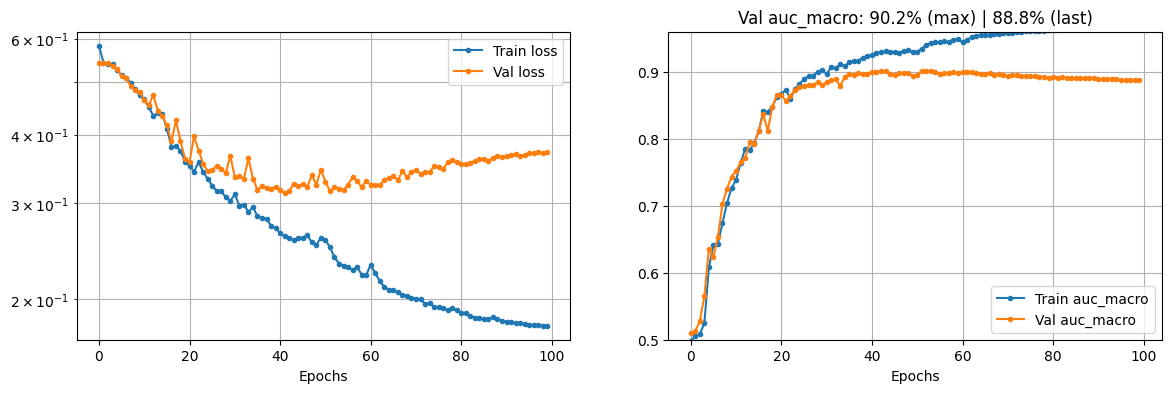

In [135]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_callback = ReduceLROnPlateau(
    monitor='val_loss',     # ou 'val_auc_macro' se você adicionou essa métrica
    factor=0.5,             # reduz LR pela metade
    patience=10,           # espera X épocas sem melhora
    min_lr=1e-6,            # limite inferior
    verbose=1
)

model = get_model()
history = train_class(model, epochs=100, batch_size=1024, lr=0.01, callbacks=[lr_callback], n_classes=5)
plots(history, ylim=[0.5, 0.96])

### Patience=5, Factor = 0.8, epochs=50, batch_size=512, lr = 0.02

0epoch [00:00, ?epoch/s]

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step - auc_macro: 0.5019 - loss: 0.5904 - val_auc_macro: 0.5817 - val_loss: 0.5332 - learning_rate: 0.0200
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - auc_macro: 0.5799 - loss: 0.5319 - val_auc_macro: 0.5394 - val_loss: 0.5546 - learning_rate: 0.0200
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - auc_macro: 0.5281 - loss: 0.5431 - val_auc_macro: 0.6329 - val_loss: 0.5258 - learning_rate: 0.0200
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - auc_macro: 0.6537 - loss: 0.5080 - val_auc_macro: 0.6962 - val_loss: 0.5015 - learning_rate: 0.0200
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - auc_macro: 0.6867 - loss: 0.4939 - val_auc_macro: 0.7354 - val_loss: 0.4846 - learning_rate: 0.0200
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - auc_macro: 0.7401 - loss: 0.4641 - val_auc_macro: 0.7714 - val_loss: 0.4510 - learning_rate: 0.0200
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - auc_macro: 0.7600 - lo

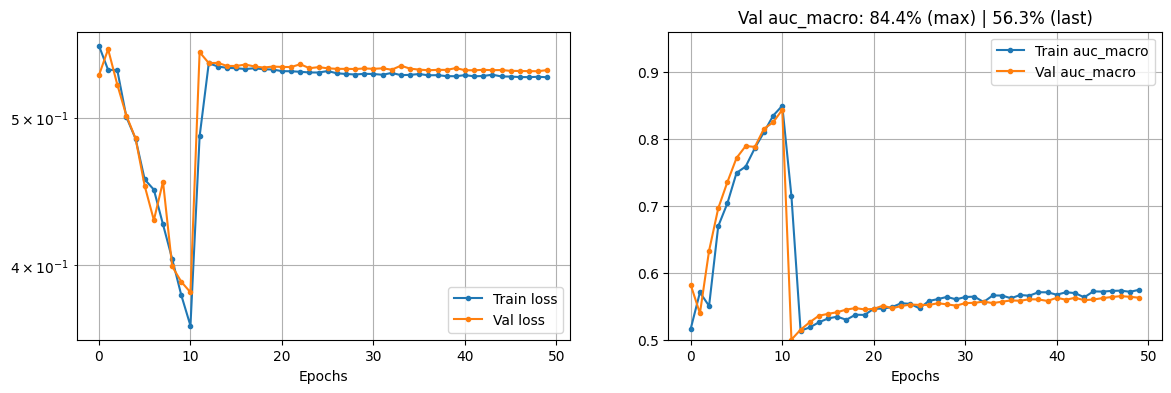

In [136]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_callback = ReduceLROnPlateau(
    monitor='val_loss',     # ou 'val_auc_macro' se você adicionou essa métrica
    factor=0.8,             # reduz LR pela metade
    patience=5,           # espera X épocas sem melhora
    min_lr=1e-6,            # limite inferior
    verbose=1
)

model = get_model()
history = train_class(model, epochs=50, batch_size=512, lr=0.02, callbacks=[lr_callback], n_classes=5)
plots(history, ylim=[0.5, 0.96])

### Patience=5, Factor = 0.7, epochs=50, batch_size=512, lr = 0.01

0epoch [00:00, ?epoch/s]

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step - auc_macro: 0.5144 - loss: 0.5862 - val_auc_macro: 0.5887 - val_loss: 0.5291 - learning_rate: 0.0100
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - auc_macro: 0.5786 - loss: 0.5329 - val_auc_macro: 0.5823 - val_loss: 0.5330 - learning_rate: 0.0100
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - auc_macro: 0.5396 - loss: 0.5418 - val_auc_macro: 0.4698 - val_loss: 0.5810 - learning_rate: 0.0100
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - auc_macro: 0.5726 - loss: 0.5425 - val_auc_macro: 0.5441 - val_loss: 0.5397 - learning_rate: 0.0100
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - auc_macro: 0.5419 - loss: 0.5384 - val_auc_macro: 0.5262 - val_loss: 0.5413 - learning_rate: 0.0100
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - auc_macro: 0.5068 - loss: 0.5415
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.006999999843537807.
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - auc_macro: 0.5069 - loss:

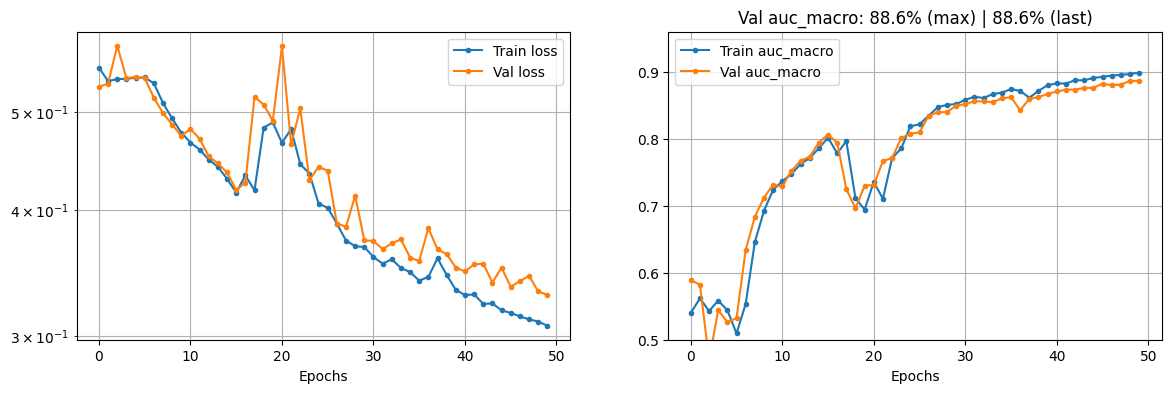

In [137]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_callback = ReduceLROnPlateau(
    monitor='val_loss',     # ou 'val_auc_macro' se você adicionou essa métrica
    factor=0.7,             # reduz LR pela metade
    patience=5,           # espera X épocas sem melhora
    min_lr=1e-6,            # limite inferior
    verbose=1
)

model = get_model()
history = train_class(model, epochs=50, batch_size=512, lr=0.01, callbacks=[lr_callback], n_classes=5)
plots(history, ylim=[0.5, 0.96])

### Melhor: factor=0.5, patience=5, min_lr=1e-6, epochs=20, batch_size=128, lr=0.01
    
    
 

0epoch [00:00, ?epoch/s]

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - auc_macro: 0.5072 - loss: 0.5641 - val_auc_macro: 0.5150 - val_loss: 0.5497 - learning_rate: 0.0100
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - auc_macro: 0.5200 - loss: 0.5438 - val_auc_macro: 0.5754 - val_loss: 0.5372 - learning_rate: 0.0100
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - auc_macro: 0.5750 - loss: 0.5343 - val_auc_macro: 0.5436 - val_loss: 0.5434 - learning_rate: 0.0100
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.5808 - loss: 0.5292 - val_auc_macro: 0.6837 - val_loss: 0.5023 - learning_rate: 0.0100
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.6723 - loss: 0.5003 - val_auc_macro: 0.6465 - val_loss: 0.5309 - learning_rate: 0.0100
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.6404 - loss: 0.5170 - val_auc_macro: 0.6820 - val_loss: 0.5099 - learning_rate: 0.0100
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - auc_macro: 0.6

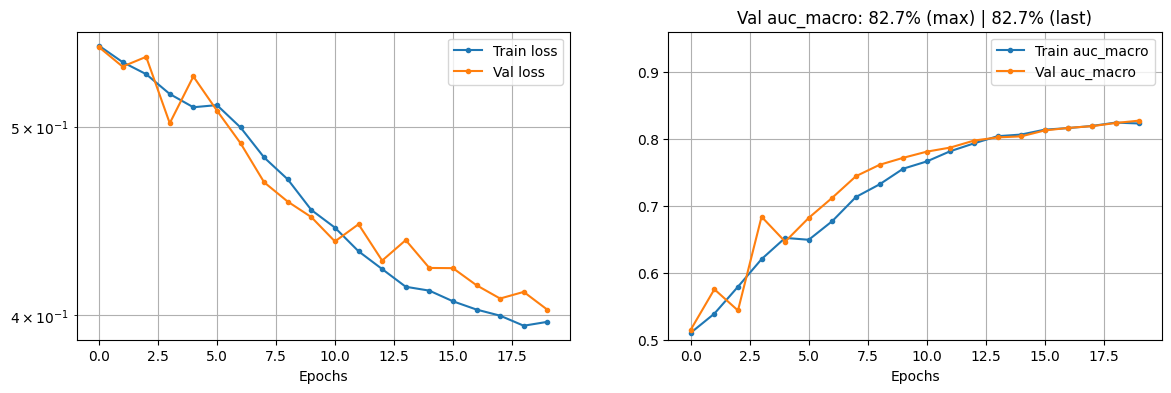

In [17]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_callback = ReduceLROnPlateau(
    monitor='val_loss',     # ou 'val_auc_macro' se você adicionou essa métrica
    factor=0.5,             # reduz LR pela metade
    patience=5,             # espera X épocas sem melhora
    min_lr=1e-6,            # limite inferior
    verbose=1
)

model = get_model()
history = train_class(model, epochs=20, batch_size=128, lr=0.01, callbacks=[lr_callback], n_classes=5)
plots(history, ylim=[0.5, 0.96])

### Observações:

Resultados são muito aleatórios, ao rodar o modelo mais de uma vez, obtem-se resultados bem diferentes. Muitas vezes o modelo chega a um bom resultado, mas ao rodar mais épocas diverge da solução ótima. Ao reduzir o lr no início, o modelo fica com underfitting, porém se aumenta a paciência ele não reduz o lr. Alternativa: Utilizar novamente o LearningRateScheduler.

## Resultados Teste

In [19]:
import pandas as pd

# Dados extraídos da imagem
dados = {
    "loss":       [0.333780, 0.371202, 0.351792, 0.306927],
    "auc_macro":  [0.889028, 0.853276, 0.868637, 0.909020],
    "auc_NORM":   [0.926611, 0.893860, 0.919697, 0.941086],
    "auc_MI":     [0.887513, 0.849386, 0.840285, 0.909609],
    "auc_STTC":   [0.903004, 0.875130, 0.894060, 0.918277],
    "auc_HYP":    [0.865178, 0.850218, 0.843744, 0.878799],
    "auc_CD":     [0.862836, 0.797785, 0.845399, 0.897331],
}

# Índices (nomes dos modelos)
index = [
    "LSTM Básico",
    "GRU Básico",
    "LSTM LearningRateScheduler",
    "GRU LearningRateScheduler"
]

# Cria o DataFrame
df_resultados_teste = pd.DataFrame(dados, index=index)

# Exibe
display(df_resultados_teste)


,loss,auc_macro,auc_NORM,auc_MI,auc_STTC,auc_HYP,auc_CD
LSTM Básico,0.333780,0.889028,0.926611,0.887513,0.903004,0.865178,0.862836
GRU Básico,0.371202,0.853276,0.893860,0.849386,0.875130,0.850218,0.797785
LSTM LearningRateScheduler,0.351792,0.868637,0.919697,0.840285,0.894060,0.843744,0.845399
GRU LearningRateScheduler,0.306927,0.909020,0.941086,0.909609,0.918277,0.878799,0.897331


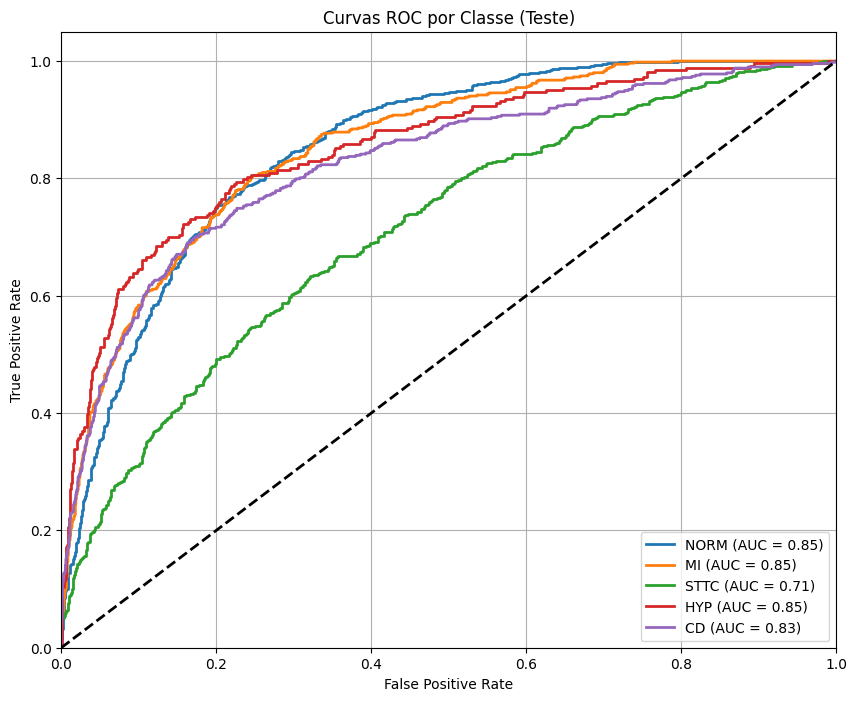

,loss,auc_macro,auc_NORM,auc_MI,auc_STTC,auc_HYP,auc_CD
LSTM Básico,0.333780,0.889028,0.926611,0.887513,0.903004,0.865178,0.862836
GRU Básico,0.371202,0.853276,0.893860,0.849386,0.875130,0.850218,0.797785
LSTM LearningRateScheduler,0.351792,0.868637,0.919697,0.840285,0.894060,0.843744,0.845399
GRU LearningRateScheduler,0.306927,0.909020,0.941086,0.909609,0.918277,0.878799,0.897331
LSTM ReduceLROnPlateau,0.406468,0.820188,0.853537,0.854405,0.712480,0.853706,0.826812


In [20]:
df_resultados_teste = avaliar_teste_ptbxl(model, x_test, y_test_class, index_name="LSTM ReduceLROnPlateau", results_df=df_resultados_teste)

display(df_resultados_teste)

## GRU

In [21]:
def get_model():
    model = keras.Sequential([
        # Entrada com sequência temporal e 12 canais (derivações do ECG)
        layers.Input(shape=(1000, 12)),  # input_len = número de amostras por traçado
        
        # LSTM com 100 unidades
        layers.GRU(100),
        
        layers.Dense(128, activation='relu'),
        # Camada densa para saída binária (ajuste se for multi-classe)
        layers.Dense(5, activation='sigmoid')  
    ])
    
    return model

get_model().summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 100)                 │          34,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │          12,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 47,773 (186.61 KB)

 Trainable params: 47,773 (186.61 KB)

 Non-trainable params: 0 (0.00 B)

## Validação

### factor=0.8, patience=2, min_lr=1e-6, epochs=20, batch_size=128, lr=0.01

0epoch [00:00, ?epoch/s]

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - auc_macro: 0.5385 - loss: 0.5644 - val_auc_macro: 0.6841 - val_loss: 0.5065 - learning_rate: 0.0100
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - auc_macro: 0.7291 - loss: 0.4715 - val_auc_macro: 0.8434 - val_loss: 0.3945 - learning_rate: 0.0100
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - auc_macro: 0.8609 - loss: 0.3586 - val_auc_macro: 0.8863 - val_loss: 0.3353 - learning_rate: 0.0100
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - auc_macro: 0.8655 - loss: 0.3550 - val_auc_macro: 0.7200 - val_loss: 0.4978 - learning_rate: 0.0100
Epoch 5/20
136/137 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - auc_macro: 0.7689 - loss: 0.4507
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.007999999821186066.
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - auc_macro: 0.7694 - loss: 0.4503 - val_auc_macro: 0.8524 - val_loss: 0.3873 - learning_rate: 0.0100
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - auc_macro: 0

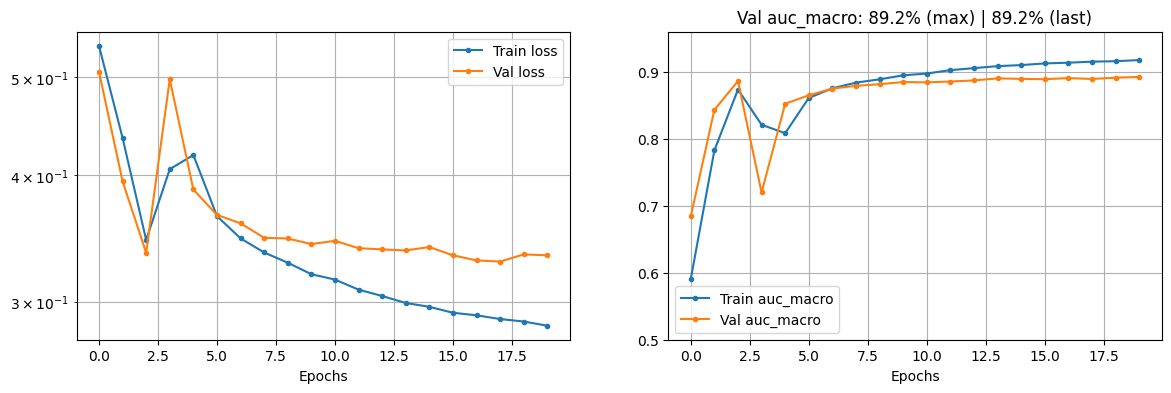

In [24]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_callback = ReduceLROnPlateau(
    monitor='val_loss',     # ou 'val_auc_macro' se você adicionou essa métrica
    factor=0.8,             # reduz LR pela metade
    patience=2,             # espera X épocas sem melhora
    min_lr=1e-6,            # limite inferior
    verbose=1
)

model = get_model()
history = train_class(model, epochs=20, batch_size=128, lr=0.01, callbacks=[lr_callback], n_classes=5)
plots(history, ylim=[0.5, 0.96])

## Teste

In [27]:
import pandas as pd

# Dados completos com os novos valores adicionados
dados = {
    "loss":       [0.333780, 0.371202, 0.351792, 0.306927, 0.406468],
    "auc_macro":  [0.889028, 0.853276, 0.868637, 0.909020, 0.820188],
    "auc_NORM":   [0.926611, 0.893860, 0.919697, 0.941086, 0.853537],
    "auc_MI":     [0.887513, 0.849386, 0.840285, 0.909609, 0.854405],
    "auc_STTC":   [0.903004, 0.875130, 0.894060, 0.918277, 0.712480],
    "auc_HYP":    [0.865178, 0.850218, 0.843744, 0.878799, 0.853706],
    "auc_CD":     [0.862836, 0.797785, 0.845399, 0.897331, 0.826812],
}

# Índices (nomes dos modelos)
index = [
    "LSTM Básico",
    "GRU Básico",
    "LSTM LearningRateScheduler",
    "GRU LearningRateScheduler",
    "LSTM ReduceLROnPlateau"
]

# Cria o DataFrame
df_resultados_teste = pd.DataFrame(dados, index=index)

# Exibe
display(df_resultados_teste)


,loss,auc_macro,auc_NORM,auc_MI,auc_STTC,auc_HYP,auc_CD
LSTM Básico,0.333780,0.889028,0.926611,0.887513,0.903004,0.865178,0.862836
GRU Básico,0.371202,0.853276,0.893860,0.849386,0.875130,0.850218,0.797785
LSTM LearningRateScheduler,0.351792,0.868637,0.919697,0.840285,0.894060,0.843744,0.845399
GRU LearningRateScheduler,0.306927,0.909020,0.941086,0.909609,0.918277,0.878799,0.897331
LSTM ReduceLROnPlateau,0.406468,0.820188,0.853537,0.854405,0.712480,0.853706,0.826812


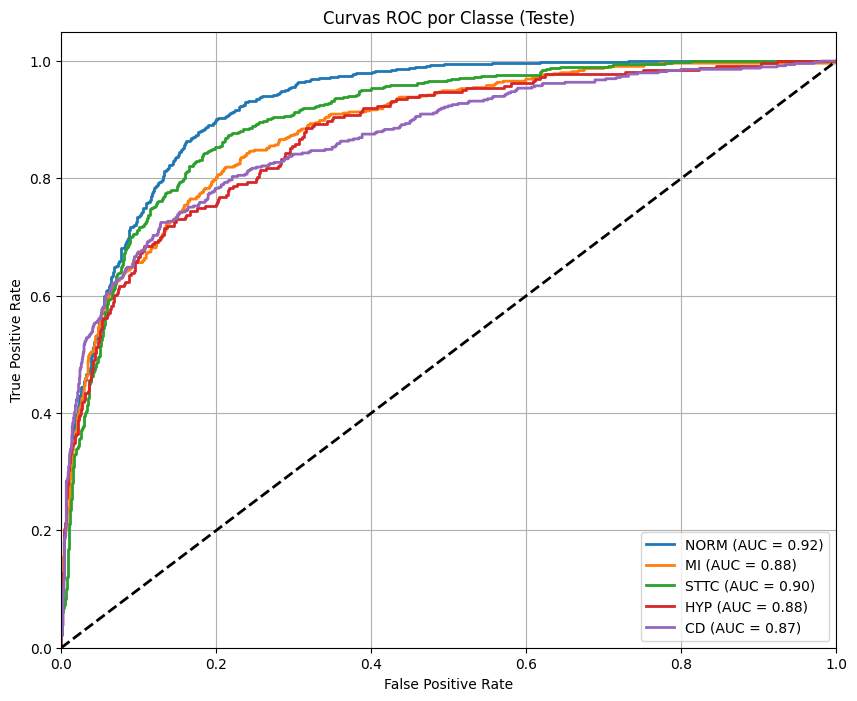

,loss,auc_macro,auc_NORM,auc_MI,auc_STTC,auc_HYP,auc_CD
LSTM Básico,0.333780,0.889028,0.926611,0.887513,0.903004,0.865178,0.862836
GRU Básico,0.371202,0.853276,0.893860,0.849386,0.875130,0.850218,0.797785
LSTM LearningRateScheduler,0.351792,0.868637,0.919697,0.840285,0.894060,0.843744,0.845399
GRU LearningRateScheduler,0.306927,0.909020,0.941086,0.909609,0.918277,0.878799,0.897331
LSTM ReduceLROnPlateau,0.406468,0.820188,0.853537,0.854405,0.712480,0.853706,0.826812
GRU ReduceLROnPlateau,0.336025,0.890402,0.924185,0.883673,0.901012,0.875028,0.868110


In [28]:
df_resultados_teste = avaliar_teste_ptbxl(model, x_test, y_test_class, index_name="GRU ReduceLROnPlateau", results_df=df_resultados_teste)

display(df_resultados_teste)

### factor=0.5, patience=5, min_lr=1e-6, epochs=20, batch_size=128, lr=0.01

0epoch [00:00, ?epoch/s]

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - auc_macro: 0.5320 - loss: 0.5591 - val_auc_macro: 0.5322 - val_loss: 0.5457 - learning_rate: 0.0100
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - auc_macro: 0.5319 - loss: 0.5382 - val_auc_macro: 0.6197 - val_loss: 0.5342 - learning_rate: 0.0100
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - auc_macro: 0.6489 - loss: 0.5130 - val_auc_macro: 0.7496 - val_loss: 0.4749 - learning_rate: 0.0100
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - auc_macro: 0.7692 - loss: 0.4428 - val_auc_macro: 0.8165 - val_loss: 0.4028 - learning_rate: 0.0100
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - auc_macro: 0.8277 - loss: 0.3916 - val_auc_macro: 0.8521 - val_loss: 0.3719 - learning_rate: 0.0100
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - auc_macro: 0.8629 - loss: 0.3568 - val_auc_macro: 0.8796 - val_loss: 0.3529 - learning_rate: 0.0100
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - auc_macr

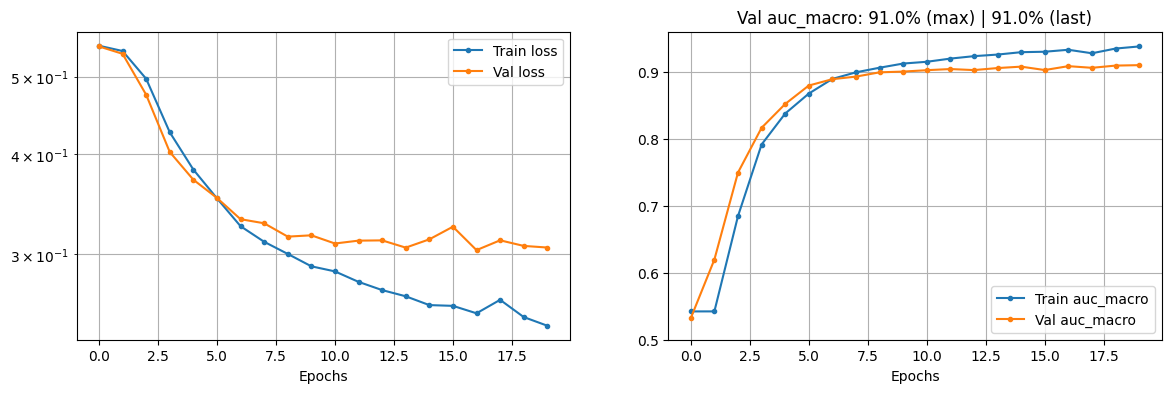

In [23]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_callback = ReduceLROnPlateau(
    monitor='val_loss',     # ou 'val_auc_macro' se você adicionou essa métrica
    factor=0.5,             # reduz LR pela metade
    patience=5,             # espera X épocas sem melhora
    min_lr=1e-6,            # limite inferior
    verbose=1
)

model = get_model()
history = train_class(model, epochs=20, batch_size=128, lr=0.01, callbacks=[lr_callback], n_classes=5)
plots(history, ylim=[0.5, 0.96])

0epoch [00:00, ?epoch/s]

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - auc_macro: 0.5633 - loss: 0.5491 - val_auc_macro: 0.8027 - val_loss: 0.4356 - learning_rate: 0.0100
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - auc_macro: 0.8262 - loss: 0.3967 - val_auc_macro: 0.8827 - val_loss: 0.3427 - learning_rate: 0.0100
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - auc_macro: 0.8904 - loss: 0.3202 - val_auc_macro: 0.8971 - val_loss: 0.3154 - learning_rate: 0.0100
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - auc_macro: 0.8963 - loss: 0.3125 - val_auc_macro: 0.8959 - val_loss: 0.3219 - learning_rate: 0.0100
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - auc_macro: 0.9085 - loss: 0.2946 - val_auc_macro: 0.9033 - val_loss: 0.3078 - learning_rate: 0.0100
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - auc_macro: 0.9194 - loss: 0.2774 - val_auc_macro: 0.9072 - val_loss: 0.3083 - learning_rate: 0.0100
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - auc_macro: 

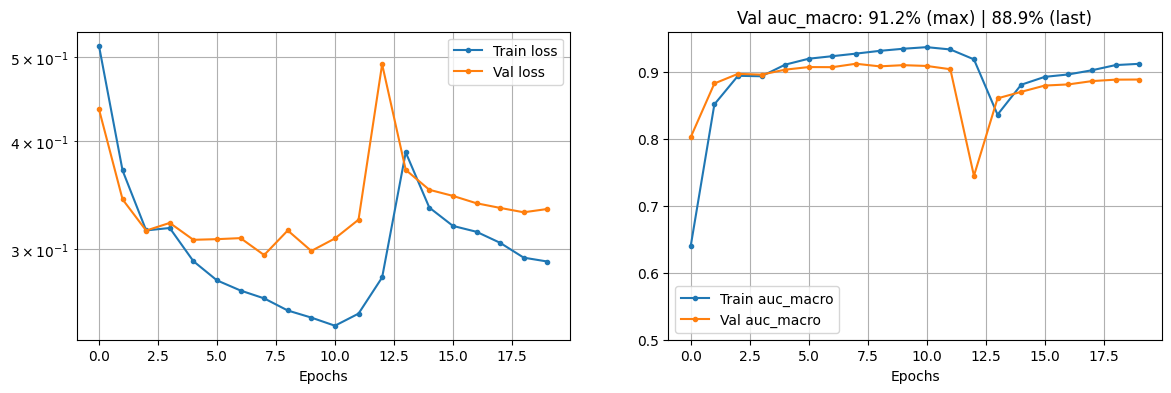

In [30]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_callback = ReduceLROnPlateau(
    monitor='val_loss',     # ou 'val_auc_macro' se você adicionou essa métrica
    factor=0.5,             # reduz LR pela metade
    patience=5,             # espera X épocas sem melhora
    min_lr=1e-6,            # limite inferior
    verbose=1
)

model = get_model()
history = train_class(model, epochs=20, batch_size=128, lr=0.01, callbacks=[lr_callback], n_classes=5)
plots(history, ylim=[0.5, 0.96])

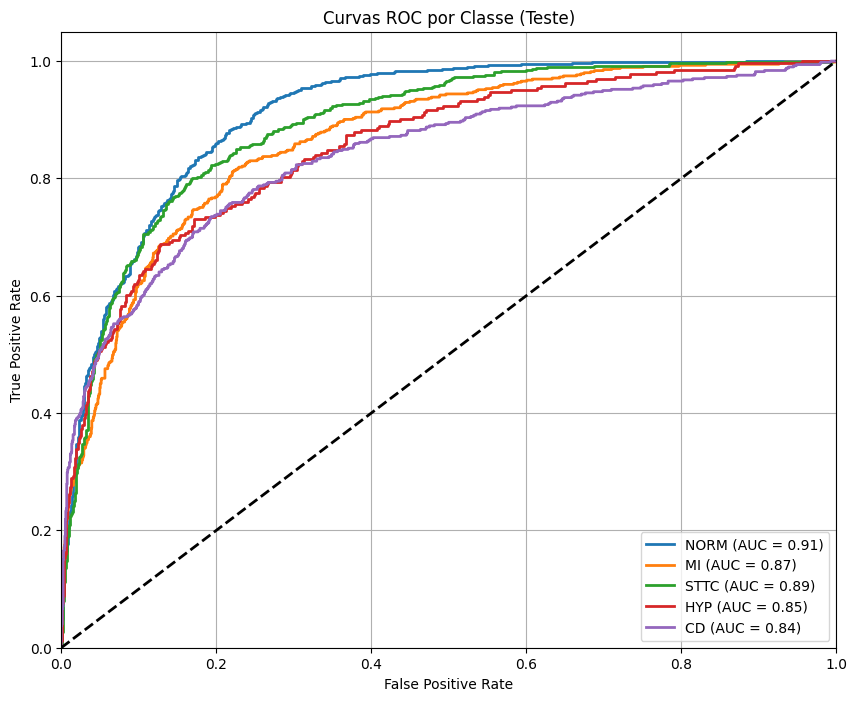

,loss,auc_macro,auc_NORM,auc_MI,auc_STTC,auc_HYP,auc_CD
LSTM Básico,0.333780,0.889028,0.926611,0.887513,0.903004,0.865178,0.862836
GRU Básico,0.371202,0.853276,0.893860,0.849386,0.875130,0.850218,0.797785
LSTM LearningRateScheduler,0.351792,0.868637,0.919697,0.840285,0.894060,0.843744,0.845399
GRU LearningRateScheduler,0.306927,0.909020,0.941086,0.909609,0.918277,0.878799,0.897331
LSTM ReduceLROnPlateau,0.406468,0.820188,0.853537,0.854405,0.712480,0.853706,0.826812
GRU ReduceLROnPlateau,0.336025,0.890402,0.924185,0.883673,0.901012,0.875028,0.868110
GRU ReduceLROnPlateau2,0.353375,0.872757,0.910786,0.867506,0.891083,0.854365,0.840048


In [31]:
df_resultados_teste = avaliar_teste_ptbxl(model, x_test, y_test_class, index_name="GRU ReduceLROnPlateau2", results_df=df_resultados_teste)

display(df_resultados_teste)

### LearningRateScheduler 5

0epoch [00:00, ?epoch/s]

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - auc_macro: 0.5389 - loss: 0.5545 - val_auc_macro: 0.7708 - val_loss: 0.4572 - learning_rate: 0.0100
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - auc_macro: 0.8231 - loss: 0.4001 - val_auc_macro: 0.8815 - val_loss: 0.3497 - learning_rate: 0.0100
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - auc_macro: 0.8918 - loss: 0.3209 - val_auc_macro: 0.8943 - val_loss: 0.3247 - learning_rate: 0.0100
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - auc_macro: 0.9075 - loss: 0.2947 - val_auc_macro: 0.8993 - val_loss: 0.3293 - learning_rate: 0.0100
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - auc_macro: 0.9184 - loss: 0.2790 - val_auc_macro: 0.9035 - val_loss: 0.3119 - learning_rate: 0.0100
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - auc_macro: 0.9331 - loss: 0.2534 - val_auc_macro: 0.9110 - val_loss: 0.2969 - learning_rate: 0.0050
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - auc_macr

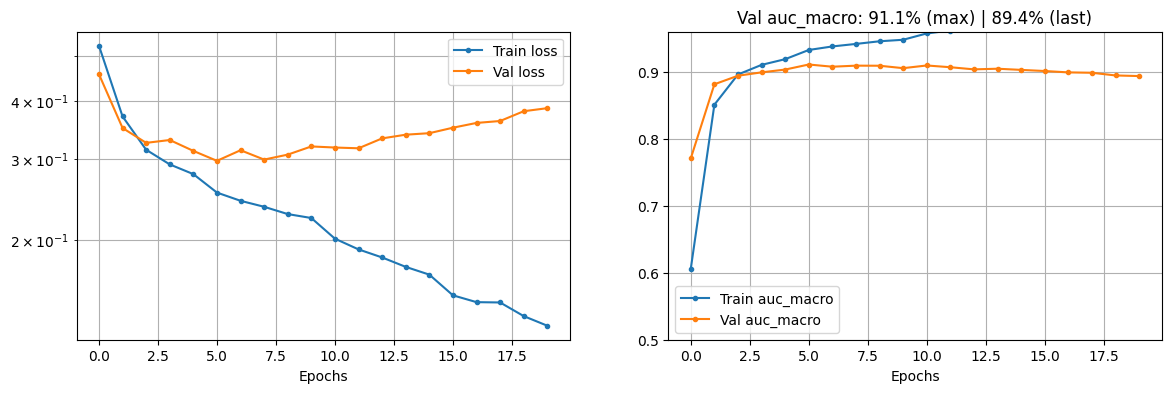

In [33]:
from tensorflow.keras.callbacks import LearningRateScheduler

# Função para decaimento da taxa de aprendizado
def scheduler(epoch, lr):
    if epoch > 0 and epoch % 5 == 0:
        return lr * 0.5
    return lr

lr_callback = LearningRateScheduler(scheduler)

model = get_model()
history = train_class(model, epochs=20, batch_size=128, lr=0.01, callbacks=[lr_callback], n_classes=5)
plots(history, ylim=[0.5, 0.96])

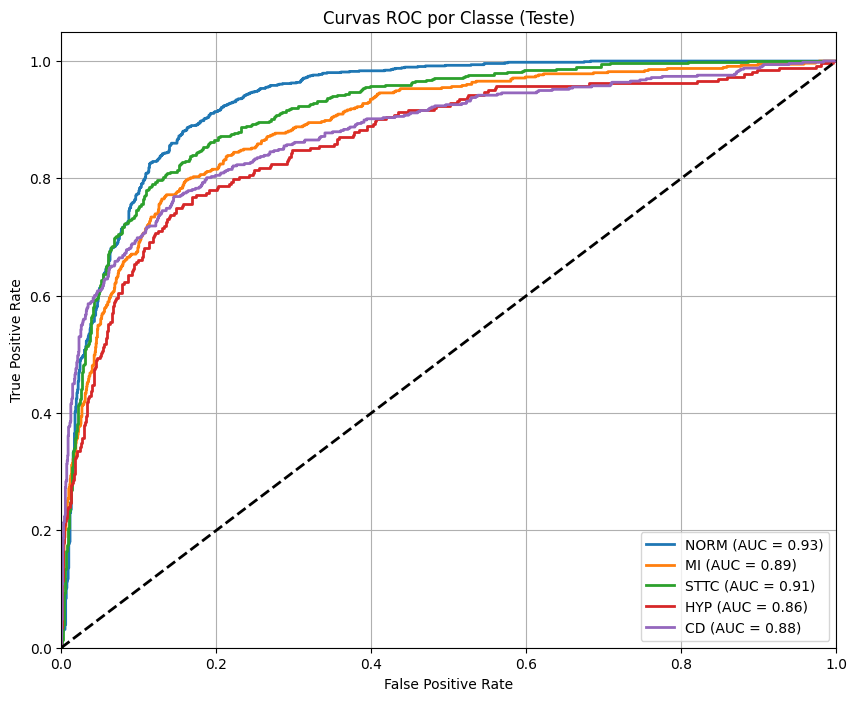

,loss,auc_macro,auc_NORM,auc_MI,auc_STTC,auc_HYP,auc_CD
LSTM Básico,0.333780,0.889028,0.926611,0.887513,0.903004,0.865178,0.862836
GRU Básico,0.371202,0.853276,0.893860,0.849386,0.875130,0.850218,0.797785
LSTM LearningRateScheduler,0.351792,0.868637,0.919697,0.840285,0.894060,0.843744,0.845399
GRU LearningRateScheduler,0.306927,0.909020,0.941086,0.909609,0.918277,0.878799,0.897331
LSTM ReduceLROnPlateau,0.406468,0.820188,0.853537,0.854405,0.712480,0.853706,0.826812
GRU ReduceLROnPlateau,0.336025,0.890402,0.924185,0.883673,0.901012,0.875028,0.868110
GRU ReduceLROnPlateau2,0.353375,0.872757,0.910786,0.867506,0.891083,0.854365,0.840048
GRU LearningRateScheduler2,0.404532,0.894456,0.931175,0.889635,0.911525,0.861656,0.878289


In [36]:
df_resultados_teste = avaliar_teste_ptbxl(model, x_test, y_test_class, index_name="GRU LearningRateScheduler2", results_df=df_resultados_teste)

display(df_resultados_teste)

# Conclusão:

Melhor modelo foi o GRU LearningRateScheduler levando em consideração o parâmetro auc_macro de teste. Porém, como esses resultados variam conforme o treinamento, é possível que outro modelo poderia se sair melhor. 